---
title: "Data Access"
format:
    html:
        toc: true
        theme: lightly
        code-fold: false
        code-links:
          - text: Download this notebook
            icon: file-code
            href: https://github.com/AllenInstitute/Teaching_Connectomics/tree/main/docs/notebooks/microns_data_access_education.ipynb
            target: _blank
          - text: Report Issue
            icon: bug
            href: https://github.com/AllenInstitute/Teaching_Connectomics/issues/new
            target: _blank
execute:
    eval: False
    warning: False
jupyter: python3
---

# Introduction to MICrONS Data Access

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AllenInstitute/Teaching_Connectomics/blob/main/docs/notebooks/microns_data_access_education.ipynb)


<b> Electron Microscopy (EM) enables morphological reconstruction of neurons and detection of their synaptic connectivity </b>. The <a href=https://www.microns-explorer.org/cortical-mm3>MICrONS dataset </a> is one of the largest datasets volume EM datasets currently available, and spans all layers of visual cortex. We will be using this dataset to query the connectivity between neurons in the visual cortex.


Begin with importing python packages:
    

In [1]:
from os.path import join as pjoin
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### CAVE account setup

<p>In order to manage server traffic, every user needs to create a CAVE account and download a user token to access CAVE's services programmatically. The CAVE infrastructure can be read about in <a href='https://www.nature.com/articles/s41592-024-02426-z'>more detail in the CAVE Paper</a>.
    
<p>The MICrONS data is publicly available which means that no extra permissions need to be given to a new user account to access the data. Bulk downloads of some static data are also available without an account on <a href='https://microns-explorer.org/'> MICrONs Explorer</a>.

<b> A Google account (or Google-enabled account) is required to create a CAVE account. </b>

<p> Go to: <a href=https://global.daf-apis.com/auth/api/v1/user/token> https://global.daf-apis.com/auth/api/v1/user/token </a>to view a list of your existing tokens
<p> If you have never made a token before:
<ol>
  <li>go here: <a href=https://global.daf-apis.com/sticky_auth/api/v1/tos/2/accept>https://global.daf-apis.com/sticky_auth/api/v1/tos/2/accept</a> to accept terms of service</li>
  <li>then go here <a href=https://global.daf-apis.com/auth/api/v1/create_token> https://global.daf-apis.com/auth/api/v1/create_token</a> to create a new token.</li>
</ol>

In [ ]:
%%capture
!uv pip install caveclient
!uv pip install cloud-volume
!uv pip install ossify

In [ ]:
from caveclient import CAVEclient

my_token = "MY_TOKEN"
client = CAVEclient("minnie65_public", auth_token=my_token)

#### Optional: Setup a persisent token for CAVE authentication

**Cloud versions: colab.**

If you have already set up a CAVE token secret as [in this example](https://colab.research.google.com/github/AllenInstitute/Teaching_Connectomics/blob/main/docs/notebooks/caveclient_setup_colab.ipynb), you can instead use:

```
from google.colab import userdata
import caveclient
client = caveclient.CAVEclient('minnie65_public',
                               auth_token=userdata.get('CAVE_TOKEN'))
```

**Local versions: Jupyter or VScode**
   
<p>If you are running this on your local machine rather than colab, you may also store the token on your machine. This makes future access easier as you do not have to specify the token.

```
client.auth.save_token(token=my_token, overwrite=True)

```

And thereafter initialize CAVE with:

```
client = CAVEclient("minnie65_public")
```

The python package `ossify` provides skeleton downloading, processing, analysis, and many convenience functions. Including loading cells directly from connectomics databases using CAVEclient. For documentation, see [Ossify](https://csdashm.com/ossify/).

And `cloud-volume` translates the complicated three-dimensional neuron objects you see in neuroglancer into arrays and meshes for you to work with analytically.  

We will import these later as needed.

## Part 1: Neuron morphology: representing neurons as skeletons

Often in thinking about neurons, you want to measure things along a linear dimension of a neuron.

However, the segmentation and meshes are a complex 3D shape that makes this non-trivial. There are methods for reducing the shape of a segmented neuron down to a linear tree like structure usually referred to as a skeleton. CAVE `Skeleton Service` automatically generates skeletons for a large number of cells in the dataset, and make the skeleton generation available on demand.

Note: The meshes you see in Neuroglancer are available to download through the python client `cloud-volume`, and can be loaded for analysis and visualization in other tools. This is useful for some types of analysis (and for making beautiful renders of neurons), but we will not cover that in this course.

Now we will select one neuron based on its root_id, the 18-digit number you see in neuroglancer, for example from:
> <https://spelunker.cave-explorer.org/#!gs://microns-static-links/mm3/layer5_thick_tufted.json>

<mark> Instructor modifications/additions: </mark> You can ask students to try this with different root ids or defined list from Dash Apps to look at and discuss morphology. If you dont have a list then students can also query proofread list and plot some skeletons (but this would need them to define a list.

In [3]:
import ossify

# Load basic cell (skeleton + L2 graph)
root_id = 864691135774053371 # known Layer 2/3 cell at v1718

cell = ossify.load_cell_from_client(
    root_id=root_id,
    client=client,
)

print(f"Loaded cell {cell.name}")
print(f"Skeleton: {cell.skeleton.n_vertices} vertices")
print(f"Graph: {cell.graph.n_vertices} L2 vertices")

Loaded cell 864691135774053371
Skeleton: 4893 vertices
Graph: 11542 L2 vertices


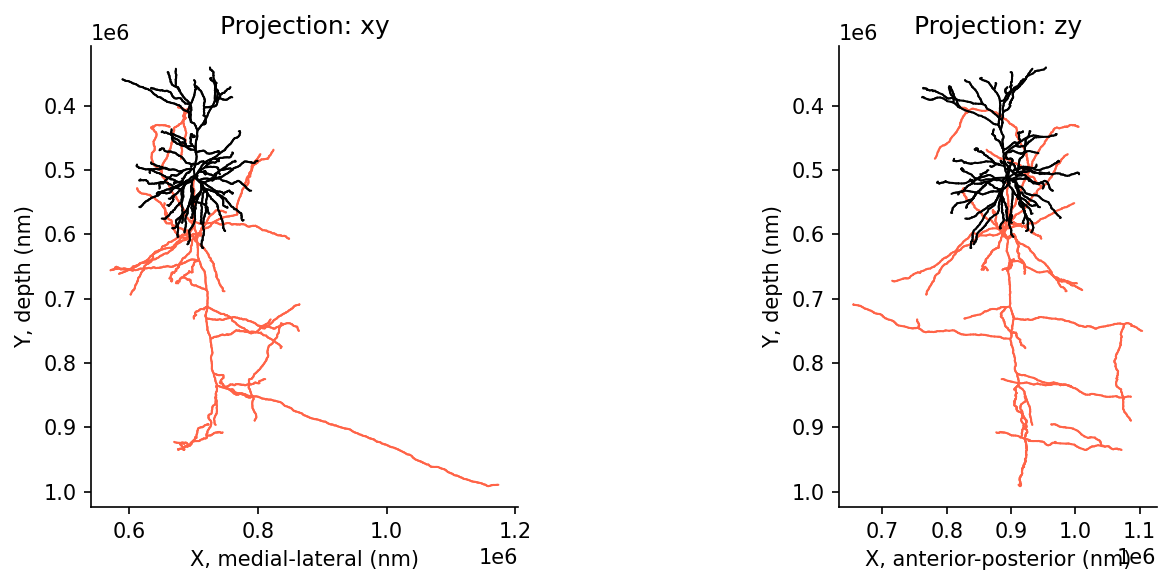

In [4]:
# @title Figure 1: Skeleton representation in 2D

# Plot different 2D projections
projections = ["xy", "zy"] # , 'xz']
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

for i, proj in enumerate(projections):
    ossify.plot.plot_morphology_2d(
        cell,
        projection=proj,
        color="compartment",
        palette={1: 'navy', 2: 'tomato', 3: 'black'}, # color scheme for axon, dendrite
        ax=axes[i]
    )
    axes[i].set_title(f"Projection: {proj}")
    axes[i].set_ylabel(f"(nm)")
    axes[i].set_xlabel(f"(nm)")
    axes[i].set_aspect("equal")

axes[0].set(xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
axes[1].set(xlabel='X, anterior-posterior (nm)', ylabel='Y, depth (nm)')
sns.despine()
plt.tight_layout()
plt.show()

The compartment labels here are: black for dendrites, and tomato for axon.

#### Transformed coordinate system

A note on the coordinate system: the MICrONS raw data you see in neuroglancer is in 'real' Voxel space where each coordinate is in the thousands. Not only are these units large, the offset is arbitrary and it would make much more sense to anchor y=0 to the pial surface. But when working with data analysis, we want a more comprehensible numbers for comparison.

The skeleton above is plotted in **nanometer coordinates**, which differs from neuroglancer. In general, there are three types of coordinates you may encounter and it is worth being deliberate in which system you use.

1. <b>Voxel coordinates</b> are the coordinates of a point in the original image volume. These are the coordinates that are used to index into the volumes you can see in Neuroglancer, but each number has a potentially different unit. In the MICrONs data, a voxel is 4 nm wide in the x and y directions, and 40 nm long in the z direction. This means that a 1x1x1 micron cube would be represented by a 250x250x25 voxel span. Annotations (such as synapses) are stored in voxel coordinates.
2. <b>Nanometer coordinates</b> are the coordinates of a point in the original image volume, but in nanometers. This is equivalent to the voxel coordinate multiplied by the voxel resolution, with no further transformation applied. Mesh and skeleton vertices are stored in nanometer coordinates.
3. <b>Transformed coordinates</b> reflect a trasnsformation that has been applied to the original image volume. This transformation is a rotation to make the pia surface as flat as possible, a translation to move the pial surface to y=0, and a scaling to bring coordinates into microns. Transformed coordinates are convenient for more accurate computations of depth and the pia-to-white-matter axis, but are not stored by default.For documentation, see [Standard Transform](https://github.com/ceesem/standard_transform).

### Adding synapse positions to skeleton

Synapses are automatically detected and assigned in the dataset. That means we 'know' all of the inputs to and outputs from our cell of interest. Let's collect that data:

**Note** this cell takes about a minute to run. It is pulling more data than the previous code `load_cell` call

In [6]:
# Load skeleton with synaptic features
root_id = 864691135774053371 # known Layer 2/3 cell at v1718

cell = ossify.load_cell_from_client(
    root_id=root_id,
    client=client,
    synapses=True, # optional argument to load synapses with skeleton
    include_partner_root_id=True, # optional argument to load partner root ids with synapses
)

print(f"Loaded cell {cell.name}")
print(f"Skeleton: {cell.skeleton.n_vertices} vertices")
print(f"Graph: {cell.graph.n_vertices} L2 vertices")

# All annotations in the cell
cell.annotations.describe()

Loaded cell 864691135774053371
Skeleton: 4893 vertices
Graph: 11542 L2 vertices
# Annotations (2)
├── pre_syn (PointCloudLayer)
│   ├── 383 vertices
│   ├── features: [created, deleted, post_pt_position_x, post_pt_position_y, post_pt_position_z, post_pt_root_id, 
│       post_pt_supervoxel_id, pre_pt_l2_id, pre_pt_position_x, pre_pt_position_y, pre_pt_position_z, pre_pt_root_id, 
│       pre_pt_supervoxel_id, size]
│   └── Links: graph <-> pre_syn
└── post_syn (PointCloudLayer)
    ├── 4794 vertices
    ├── features: [created, deleted, post_pt_l2_id, post_pt_position_x, post_pt_position_y, post_pt_position_z, 
│       post_pt_root_id, post_pt_supervoxel_id, pre_pt_position_x, pre_pt_position_y, pre_pt_position_z, pre_pt_root_id, 
│       pre_pt_supervoxel_id, size]
    └── Links: graph <-> post_syn


In [8]:
# Synapse dataframe attached to skeleton
pre_syn_df = cell.annotations.pre_syn.nodes
post_syn_df = cell.annotations.post_syn.nodes

# return the available columns to line
pre_syn_df.columns

Index(['created', 'deleted', 'pre_pt_position_x', 'pre_pt_position_y',
       'pre_pt_position_z', 'post_pt_position_x', 'post_pt_position_y',
       'post_pt_position_z', 'ctr_pt_position_x', 'ctr_pt_position_y',
       'ctr_pt_position_z', 'size', 'pre_pt_supervoxel_id', 'pre_pt_root_id',
       'post_pt_supervoxel_id', 'post_pt_root_id', 'pre_pt_l2_id'],
      dtype='object')

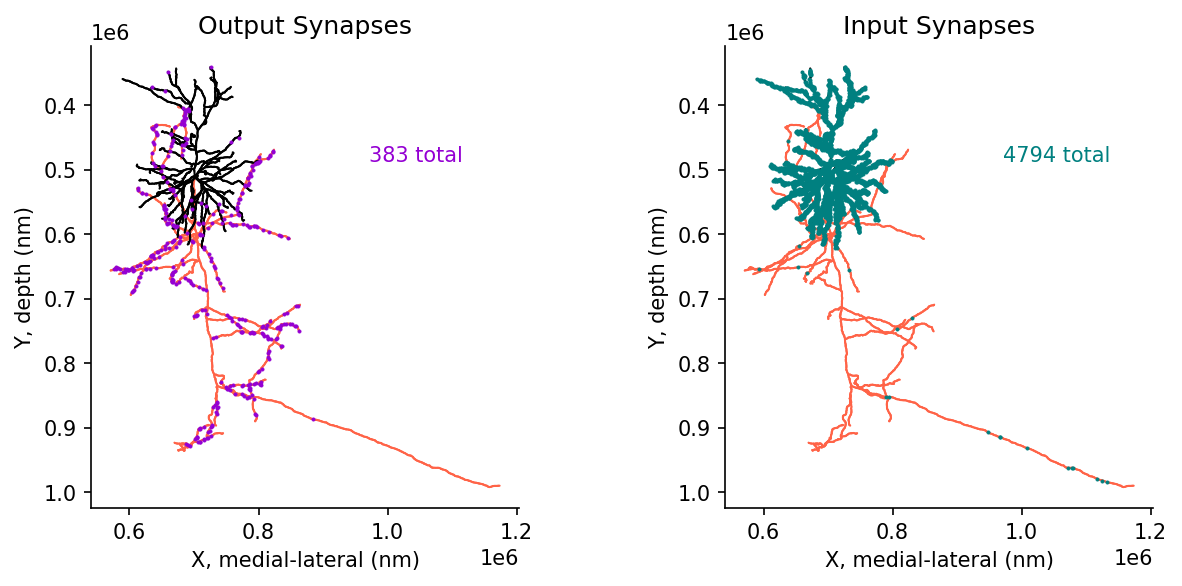

In [9]:
# @title Figure 2: Skeleton with synaptic inputs and outputs

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

for i in range(2):
    ossify.plot.plot_morphology_2d(cell,
                                   projection="xy",
                                   color="compartment",
                                   palette={1: 'navy', 2: 'tomato', 3: 'black'},
                                   ax=ax[i])

# Output synapses
sns.scatterplot(data=pre_syn_df, x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=3, color="darkviolet", ax=ax[0], edgecolor=None, zorder=100)
ax[0].text(.65,.75,f'{len(pre_syn_df)} total', color='darkviolet',  transform = ax[0].transAxes)


# Input synapses
sns.scatterplot(data=post_syn_df, x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=3, color="teal", ax=ax[1], edgecolor=None, zorder=100)
ax[1].text(.65,.75,f'{len(post_syn_df)} total', color='teal',  transform = ax[1].transAxes)

ax[0].set(title="Output Synapses", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
ax[1].set(title="Input Synapses", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')

sns.despine()
plt.show()

#### Examine the synapses for a cell of interest

Now we have all the inputs and outputs to thise cell.


In [10]:
pre_syn_df.head()[['pre_pt_root_id','post_pt_root_id','size','ctr_pt_position_x','ctr_pt_position_y','ctr_pt_position_z']]

,pre_pt_root_id,post_pt_root_id,size,ctr_pt_position_x,ctr_pt_position_y,ctr_pt_position_z
id,,,,,,
166117160,864691135774053371,864691136813865843,16400.0,725976,637136,939920
169400050,864691135774053371,864691136053342195,31012.0,719064,686056,1009920
131397678,864691135774053371,864691135616414057,6288.0,642528,444664,961200
140645129,864691135774053371,864691135278991265,8556.0,666712,673752,716480
188081937,864691135774053371,864691135448157330,668.0,774584,535336,938680


We could also have gotten the same thing (synapses for our cell of interest), without getting the skeleton, as follows:

```
# Inputs synapses: Query synapse table with synapse_query()
post_syn_df = client.materialize.synapse_query(post_ids=root_id)

# Output synapses: Query synapse table with synapse_query()
pre_syn_df = client.materialize.synapse_query(pre_ids=root_id)

```

The `synapse_query` function allows you to query the synapse table in a more convenient way than most other tables.
In particular, the `pre_ids` and `post_ids` let you specify which root id (or collection of root ids) you want to query, with pre_ids indicating the collection of **presynaptic neurons** and post_ids the collection of **postsynaptic neurons**.

Using both `pre_ids` and `post_ids` in one call is effectively a logical AND, returning only those synapses from neurons in the list of `pre_ids` that target neurons in the list of `post_ids`.

Note that synapse queries always return the list of every synapse between the neurons in the query, even if there are multiple synapses between the same pair of neurons.

A common pattern to generate a list of connections between unique pairs of neurons is to group by the root ids of the presynaptic and postsynaptic neurons and then count the number of synapses between them.
For example, use `pandas.groupby()` to get the number of synapses from this neuron onto every other neuron:

In [11]:
# get count of synapses between presynaptic and postsynaptic partners
output_connectivity = (pre_syn_df.groupby(['pre_pt_root_id', 'post_pt_root_id'])
 .count()[['size']]
 .rename(columns={'size': 'syn_count'})
 .sort_values( by='syn_count', ascending=False,)
)

output_connectivity
# Note that the 'size' part here is just a way to quickly extract one column. This could be any of the remaining column names.

syn_count
pre_pt_root_id     post_pt_root_id              
864691135774053371 864691135739751793          4
                   864691135478095016          3
                   864691135698460826          3
                   864691135562001633          3
                   864691135685635058          3
...                                          ...
                   864691133746402299          1
                   864691133759817856          1
                   864691133777723880          1
                   864691133799203959          1
                   864691136438469534          1

[341 rows x 1 columns]

<mark>Student task: copy the pre_pt_root_id and top post_pt_root_id into neuroglancer. Can you find one of the synapses between them?</mark> How long did it take you? Wouldn't it be so much easier if you know exactly the point where the synapse is already?

Hint: `client.materialize.synapse_query` above returns the position information in voxel coordinates (same as neuroglancer)


<mark>Student task: Can you create a dataframe/list of inputs to this specific neuron?</mark>


In [12]:
# get count of synapses between presynaptic partners
input_connectivity = (post_syn_df.groupby(['pre_pt_root_id', 'post_pt_root_id'])
 .count()[['size']]
 .rename(columns={'size': 'syn_count'})
 .sort_values( by='syn_count', ascending=False,)
)

input_connectivity


,,syn_count
pre_pt_root_id,post_pt_root_id,
864691135562001633,864691135774053371,18
864691135720572977,864691135774053371,17
864691135939776309,864691135774053371,17
864691135698460826,864691135774053371,16
864691135215217280,864691135774053371,11
...,...,...
864691132331311807,864691135774053371,1
864691132314768861,864691135774053371,1
864691137056011126,864691135774053371,1


#### Proofreading considerations for inputs vs outputs

As you saw when exploring the data, there are many reconstruction 'errors' or artifacts in the data. Some of these are 'merge' errors where multiple axons are merged together, or a glial cell is merged to a neurite.

Some of these are 'truncation' errors, where the axon ends before it should be. These two kinds of errors impact analysis differently. While split errors reduce the number of correct synaptic connections, merge errors add incorrect connections.

The frequency of errors is roughly related to the size, and so axons and dendrites have extremely different error profiles. Dendrites, because they are thicker, are largely correct. **Most dendrites in the dataset are connected to their soma**.

In contrast, axons, because they are thinner, have many more errors of both kinds. **Most axons in the dataset are NOT connected to their soma, without manual proofreading**.

Let's look at what that asymmetry means for what we know about our neuron's inputs and outputs:

In [13]:
# get the root_ids that have a "known" soma
soma_df= client.materialize.views.nucleus_detection_lookup_v1().query(
    select_columns = ['id','pt_root_id']
)

# Filter output synapses to known postsynaptic cells
pre_syn_to_known_df = pre_syn_df.loc[pre_syn_df.post_pt_root_id.isin(soma_df.pt_root_id)]

# Filter input synapses from known postsynaptic cells
post_syn_from_known_df = post_syn_df.loc[post_syn_df.pre_pt_root_id.isin(soma_df.pt_root_id)]

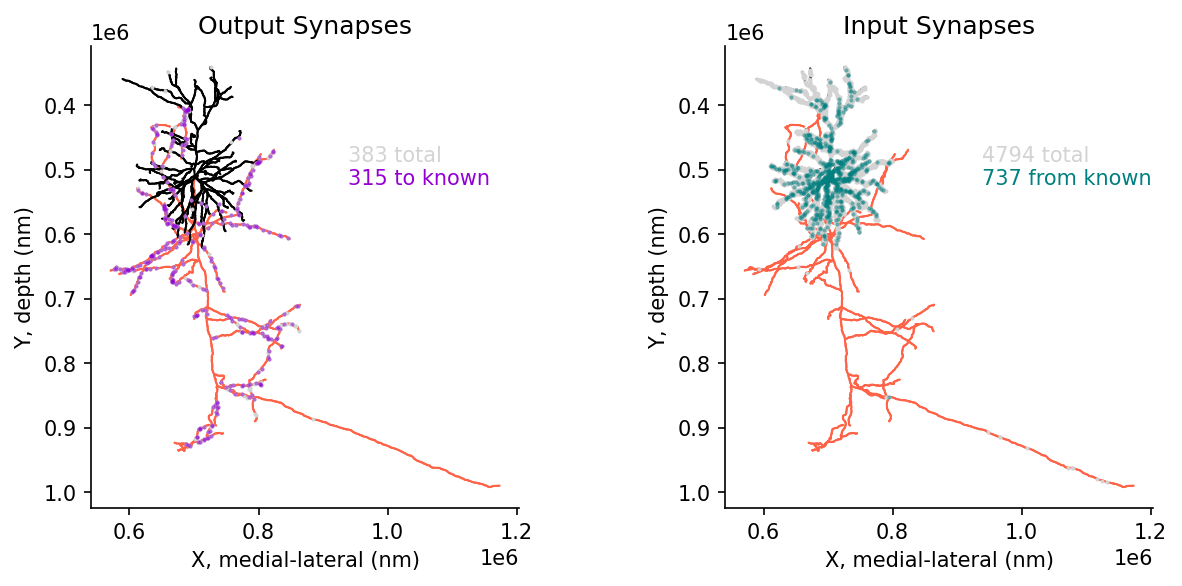

In [14]:
# @title Figure 3: Skeleton with inputs and outputs, filtered by 'known' connections

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

point_size = 3

for i in range(2):
    ossify.plot.plot_morphology_2d(cell,
                                   projection="xy",
                                   color="compartment",
                                   palette={1: 'navy', 2: 'tomato', 3: 'black'},
                                   ax=ax[i])
# Output synapses
sns.scatterplot(data=pre_syn_df, x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=point_size, color="lightgrey", ax=ax[0], edgecolor=None, zorder=100)
sns.scatterplot(data=pre_syn_to_known_df, x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=point_size, color="darkviolet", ax=ax[0], edgecolor=None, zorder=100, alpha=0.5)
ax[0].text(.6,.75,f'{len(pre_syn_df)} total', color='lightgrey',  transform = ax[0].transAxes)
ax[0].text(.6,.7,f'{len(pre_syn_to_known_df)} to known', color='darkviolet',  transform = ax[0].transAxes)

# Input synapses
sns.scatterplot(data=post_syn_df, x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=point_size, color="lightgrey", ax=ax[1], edgecolor=None, zorder=100)
sns.scatterplot(data=post_syn_from_known_df, x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=point_size, color="teal", ax=ax[1], edgecolor=None, zorder=100, alpha=0.5)
ax[1].text(.6,.75,f'{len(post_syn_df)} total', color='lightgrey',  transform = ax[1].transAxes)
ax[1].text(.6,.7,f'{len(post_syn_from_known_df)} from known', color='teal',  transform = ax[1].transAxes)

ax[0].set(title="Output Synapses", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
ax[1].set(title="Input Synapses", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
sns.despine()
plt.show()

#### Synapse target compartment

Different synapses can target different compartments on the post synaptic cell: **dendritic spine, dendritic shaft, or soma**.

![Diagram and synapse compartment classification from: [A quantitative census of millions of postsynaptic structures in a large electron microscopy volume of mouse visual cortex (Pedigo et al.)](https://www.biorxiv.org/content/10.64898/2026.02.19.706834v1).](https://raw.githubusercontent.com/AllenInstitute/connectomics_at_cosyne/refs/heads/main/docs/resources/sss-diagram.png)

Synapses on a dendritic spine effect the membrane potential of a much smaller, isolated volume that decays to baseline slower. And so excitatory (glutamatergic) inputs have the possibility of 'summating' with multiple inputs nearby into a larger membrane potential that may initiate an action potential.

Whereas synapses onto the soma of neurons are especially strong for 'shunting' membrane potential, stopping axons potentials from triggering, and are almost exlusively inhibitory (GABAergic) synapses.

These annotaitons are available as CAVE table: `synapse_target_predictions_ssa_v2`.

Let's visualize this for out example **Layer 2/3 neuron** from Part 1:

The basic querying logic of CAVE is `client.materialize.tables`. This takes a table of interest, for us `synapse_target_predictions_ssa_v2` and queries the information requested from the server:

In [15]:
# Synapse dataframe attached to skeleton
pre_syn_df = cell.annotations.pre_syn.nodes
post_syn_df = cell.annotations.post_syn.nodes

# Add spine information to outputs
output_synapse_tags = client.materialize.tables.synapse_target_predictions_ssa_v2(id=pre_syn_df.index).query(
    select_columns={'synapses_pni_2': ['id'], # reference id for synapse table
                    'synapse_target_predictions_ssa_v2': ['tag'], # compartment label
                   }
).set_index('id')

pre_syn_df = (pre_syn_df.merge(output_synapse_tags, left_index=True, right_index=True, how='left')
              .rename(columns={'tag': 'Target'})
              .fillna({'Target': 'none'})
             )

# Add spine information to inputs
input_synapse_tags = client.materialize.tables.synapse_target_predictions_ssa_v2(id=post_syn_df.index).query(
    select_columns={'synapses_pni_2': ['id'], # reference id for synapse table
                    'synapse_target_predictions_ssa_v2': ['tag'], # compartment label
                   }
).set_index('id')

post_syn_df = (post_syn_df.merge(input_synapse_tags, left_index=True, right_index=True, how='left')
               .rename(columns={'tag': 'Target'})
               .fillna({'Target': 'none'})
             )


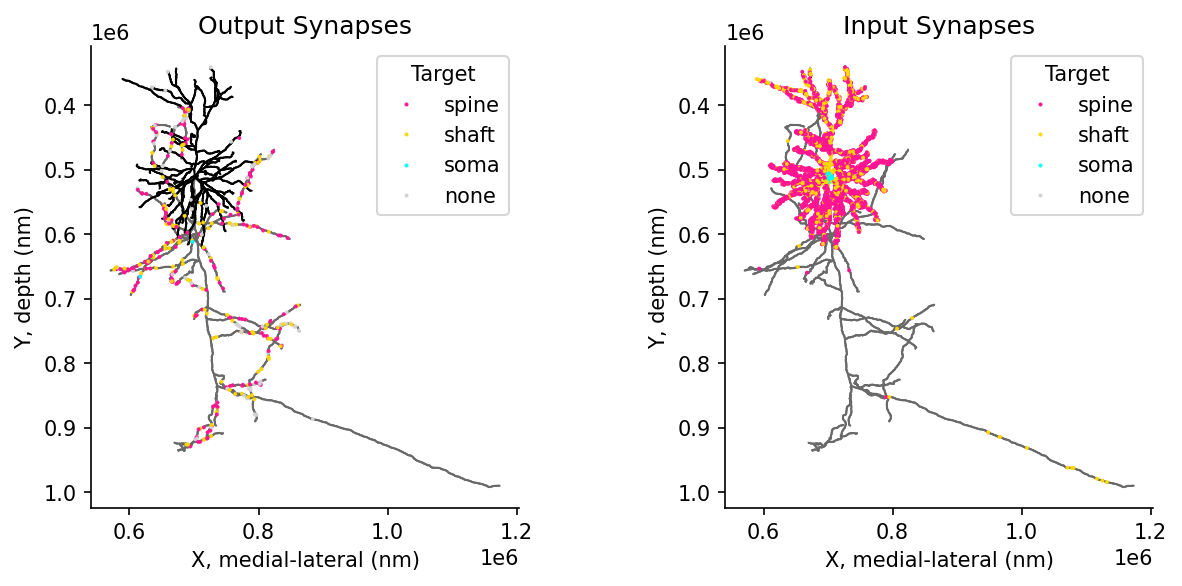

In [16]:
# @title Figure 4: Synaptic target compartments: spine, shaft, soma

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

point_size = 3

for i in range(2):
    ossify.plot.plot_morphology_2d(cell,
                                   projection="xy",
                                   color="compartment",
                                   palette={1: 'navy', 2: 'dimgrey', 3: 'black'},
                                   ax=ax[i])
# Output synapses
sns.scatterplot(data=pre_syn_df, x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=point_size, hue='Target', hue_order=['spine','shaft','soma','none'],
                palette={'spine': 'deeppink','shaft': 'gold', 'soma':'cyan', 'none': 'lightgrey'},
                ax=ax[0], edgecolor=None, zorder=100)


# Input synapses
sns.scatterplot(data=post_syn_df, x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=point_size, hue='Target', hue_order=['spine','shaft','soma','none'],
                palette={'spine': 'deeppink','shaft': 'gold', 'soma':'cyan', 'none': 'lightgrey'},
                ax=ax[1], edgecolor=None, zorder=100)


ax[0].set(title="Output Synapses", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
ax[1].set(title="Input Synapses", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
sns.despine()
plt.show()

## Part 2: Synaptic Connectivity

Above we looked at one neuron and its synapses in isolation. Now we are going to think about many synapses, from many neurons across the population

<em> Note on data access: </em> To speed up of this analysis, we already collected some of the data needed for this exercise from the database. We have made it available as versioned files that can be read with pandas. A separate `preprocessing` notebook shows how to use CAVEclient to generate the files used in this notebook.

In [17]:
materialization_version = 1718 # Current public as of March 2026
data_url = "https://github.com/AllenInstitute/connectomics_at_cosyne/raw/refs/heads/main/docs/resources/data"

# Load the curated cell types table
cell_types_df = pd.read_csv(pjoin(data_url, f'v{materialization_version}_cell_info.csv'))

### Visualize axon-proofread cells in the dataset

When we are talking about **connectivity** between two neurons in the MICrONS dataset, we require that the 'input' neuron, the postsynaptic neuron, be proofread. As described above, the frequency of errors is roughly related to the size. Dendrites are largely correct. We can trust the inputs to most dendrites in the dataset are connected to their soma.

Axons, because they are thinner, have many more errors. Here we only analyze those out outputs with manual proforeading. Fortunately, there are thousands of proofread cells in this dataset!

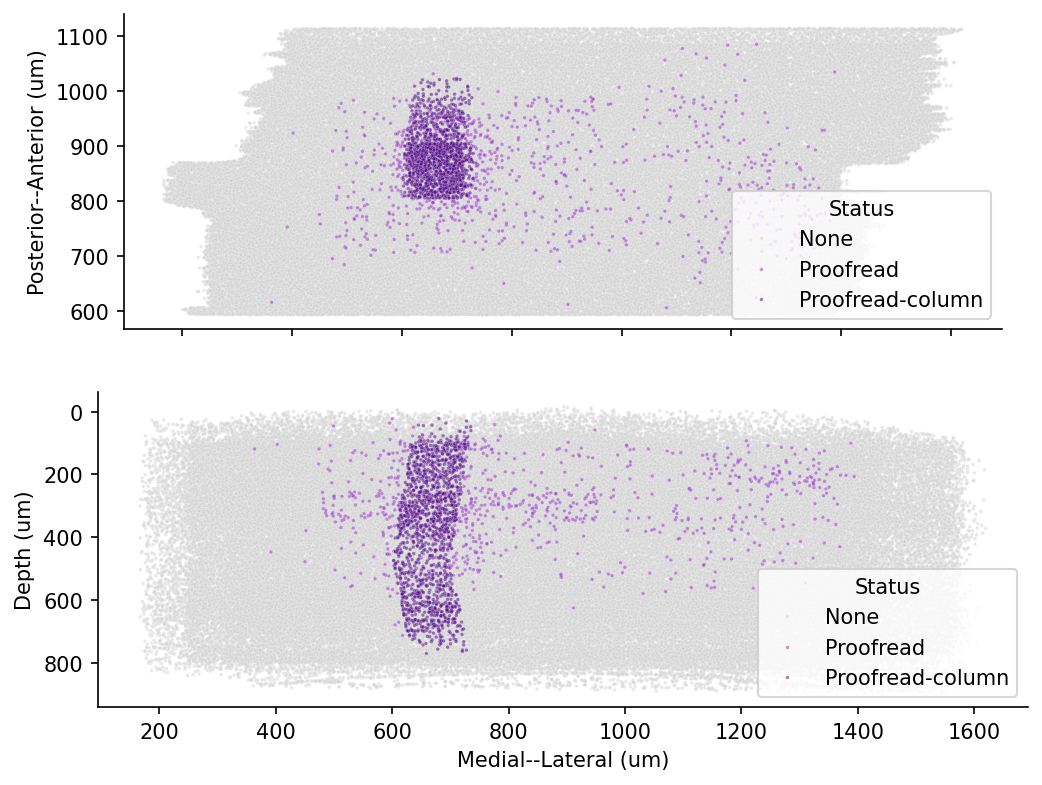

In [18]:
# @title Figure 5: Spatial position of neurons in MICrONS

fig, ax = plt.subplots(2,1, figsize=(8, 6),dpi=150, sharex=True)

# Added a labeled column for ease of plotting
cell_types_df['Status'] = 'None'
cell_types_df.loc[cell_types_df.status_axon, 'Status'] = 'Proofread'
cell_types_df.loc[cell_types_df.is_column, 'Status'] = 'Proofread-column'
cell_types_df = cell_types_df.sort_values('Status')

# Plot xz-view (top down)
sns.scatterplot(cell_types_df,
                x='pt_position_x_tform',
                y='pt_position_z_tform',
                hue='Status',
                hue_order = ['None', 'Proofread', 'Proofread-column'],
                palette={'Proofread-column': 'indigo', 'Proofread': 'darkorchid', 'None': 'lightgrey'},
                s=3,
                alpha=0.5,
                ax=ax[0]
               )
# Plot xy-view (coronal)
sns.scatterplot(cell_types_df,
                x='pt_position_x_tform',
                y='pt_position_y_tform',
                hue='Status',
                hue_order = ['None', 'Proofread', 'Proofread-column'],
                palette={'Proofread-column': 'indigo', 'Proofread': 'darkorchid', 'None': 'lightgrey'},
                s=3,
                alpha=0.5,
                ax=ax[1]
               )

sns.despine()
ax[1].invert_yaxis()
ax[0].set(xlabel='Medial--Lateral (um)', ylabel='Posterior--Anterior (um)')
ax[1].set(xlabel='Medial--Lateral (um)', ylabel='Depth (um)')
ax[0].set_aspect("equal")

### Synapse information

There are <b>337 million synapses</b> in the MICrONS dataset.

We have collected all of the input and output synapses for the proofread cells in version 1718 (March 2026). If you are interested in working with this dataset in the future, we added a `preprocessing` notebook that shows how the data was queried.

Note that synapse queries always return the list of every synapse between the neurons in the query, even if there are multiple synapses between the same pair of neurons. A common pattern to generate a list of connections between unique pairs of neurons is to group by the root ids of the presynaptic and postsynaptic neurons and then count the number of synapses between them.

<b> Here we will load all Proofread-to-Proofread connections within the V1 column, </b> a small subset of the dataset.

In [19]:
column_synapses = pd.read_feather(pjoin(data_url, f'v{materialization_version}_v1_column_synapses.feather'))
column_synapses.shape

(146711, 6)

### Connectivity matrix

The synapses of neurons create a network of connections. One way of visualizing this connectivity is in a matrix. Pandas provides the `pivot_table` function that we can use to make a matrix out of the tabular synapse data. For now, we will limit ourselves to the synapses between the proofread-column neurons.
    

<i>Note:</i> Each synapses has a `size` value assigned to it. How to aggregate the sizes from multiple synapes between two neurons depends on the research question. For now we ignore both synapse `size` and synapse `count`, and treat connection strength as <b>binary: connected or not-connected</b>

In [20]:
# matrix of synapse counts
syn_mat_binary = column_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id",
                                            values="size", aggfunc=lambda x: (np.sum(x) > 0)).fillna(0)

# Make sure matrix is quadratic
syn_mat_binary = syn_mat_binary.reindex(columns=np.array(syn_mat_binary.index)).astype(float)

row_indices, column_indices = np.nonzero(syn_mat_binary)

Number of edges: 78928
Number of possible edges: 1836025
Fraction of possible edges: 0.0430


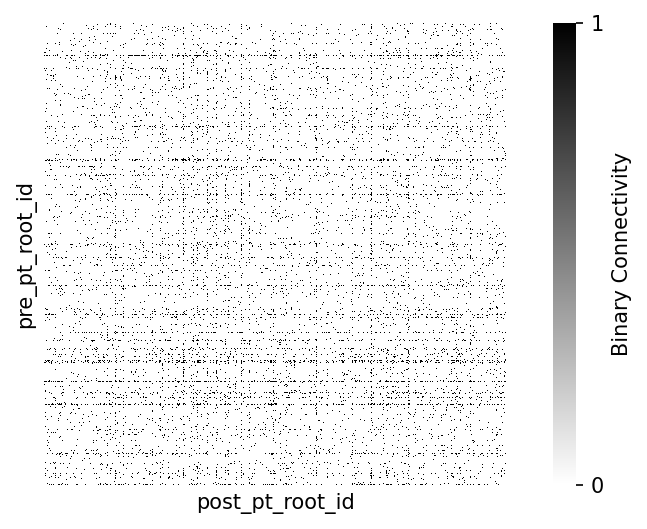

In [21]:
# @title Figure 6: Binary connectivity matrix (column-to-column)

fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
sns.heatmap(syn_mat_binary, cmap="gray_r", xticklabels=[], yticklabels=[],
            ax=ax, square=True,
            cbar_kws={"label": "Binary Connectivity", "ticks": [0, 1]})


n_edges = len(row_indices)
n_possible_edges = syn_mat_binary.shape[0] * syn_mat_binary.shape[1]
print(f"Number of edges: {n_edges}")
print(f"Number of possible edges: {n_possible_edges}")
print(f"Fraction of possible edges: {n_edges / n_possible_edges:.4f}")

<h4> Consider: different measures of synaptic strength </h4>

When creating a connectivity matrix, how you measure synaptic strength can make a difference in your analysis. For 3 common ways of reporting connection strength:

<ol>
    <li> <b> Binary connectivity:</b> whether two cells are connected at all, as shown above.</li>
    <li> <b> Synaptic count:</b> the total number of synapses that are part of the connection. This is typical of the Fly connectome where <code>count</code> captures much of the connection diversity. The modal <code>count</code> in mouse cortex is much lower.</li>
    <li> <b> Synaptic size:</b> the size of the postsynaptic density at every connection, generally aggregated as <code>sum</code> or <code>mean</code> for each unique connection.</li>
    
</ol>

We will explore these nuances in more detail in **Part 5**

## Part 3: Cell type tables

Identifying the putative ‘cell type’ from the EM morphology is a process that involves both manual and automatic classifications. Subsets of the dataset have been manually classified by anatomists at the Allen Institute, and these ground truth labels used to train and refine different automated ‘feature classifiers’ over time.

The diversity of manual and automated cell type classifications available in the dataset reflect the fact that definitions of ‘cell types’ in the dataset is an active area of research and must be contextualized against the purpose and resolution of the cell-typing being performed.

### Using the automated cell types

Many of these automated cell type definitions were established and refined for the [MICrONS Dataset](https://www.microns-explorer.org/) including:

<ul>
    <li> Perisomatic cell features <a href=https://www.nature.com/articles/s41586-024-07765-7>(Elabbady et al.)</a> </li>
    <li> Morphology and connectivity features <a href=https://www.nature.com/articles/s41586-024-07780-8>(Schneider-Mizell et al.)</a> </li>
    <li> Dendrite and spine multifeature model. The process of applying these labels is ongoing, but is available in CAVE from the <code>cell_type_multifeature_combo</code> table which labels cell types according to using soma, nucleus, dendrite, and spine features. These are colated in the `meso_type` column of our cell types dataframe.</a> </li>
</ul>


<b>For this tutorial, we will use `cell_types` from the perisomatic cell features</b>. Choose an alternate cell type classification at your discretion.

*Note:* Cells here without a label are NaN. These are either non-neuronal cells or potential neurons with large segmentation errors that did not pass quality check

In [22]:
cell_types_df.value_counts(['cell_type']).sort_index()

cell_type
23P          19650
4P           14712
5P-ET         2149
5P-IT         7890
5P-NP          932
6P-CT         6770
6P-IT        11651
BC            3354
BPC           1494
MC            2469
NGC            588
OPC           1422
astrocyte     6898
microglia     2358
oligo         6901
pericyte       374
Name: count, dtype: int64

Excitatory cells were separated into laminar sub-classes: L23 (implied IT), L4 (implied IT), 3 sub-types of layer 5 cells (ET, IT, NP) and 2 classes of layer 6 cells (IT, CT).

Inhibitory cells were classified into morphological types: Bipolar (BPC), Basket (BC), Martinotti (MC), or Neurogliaform (NGC).

Non-neuronal cell types include: astrocytes, microglia, pericytes, oligodendrocytes (oligo), and oligodendrocyte precursor cells (OPC)

### Cell Typing Features

#### Location vs depth

As a first analysis, we will plot the depth location vs the size of each cell nucleus. `query_table` has additional parameters to modify the results and standardize returns that make such an analysis easier.
* Using `desired_resolution` the resolution of all position columns can be defined in nanometers.
* Using `split_positions`, position columns are separate
* Using `select_columns` returns only the columns you know you are interested in. Try uncommenting this line to make the table more readable

In [23]:
nucleus_df = client.materialize.query_table('nucleus_detection_v0',
                                            desired_resolution=[1000, 1000, 1000], # returned in um
                                            split_positions=True,
                                            select_columns=['id','pt_root_id','volume','pt_position']
                                           )
nucleus_df.sample(5)

,id,pt_supervoxel_id,pt_root_id,volume,pt_position_x,pt_position_y,pt_position_z
16797,20191,0,0,86.243248,317,440,817
130772,200344,83125621680745781,864691136134924683,305.0224,533,844,601
131881,490903,103101343513918860,864691135885458800,309.739014,1114,575,824
36605,325780,92262014021531469,864691135700176930,250.649811,799,500,744
108753,623922,112542369026863100,864691135490934119,237.954178,1388,921,896


The data is organized such that the `y` axis is roughly aligned with depth (there is a 5 degree tilt that can be adjusted with the [standard_transform](https://github.com/CAVEconnectome/standard_transform) package; we will ignore that here for simplicity).

The plot represents spatial organization of cell nuclei in the tissue

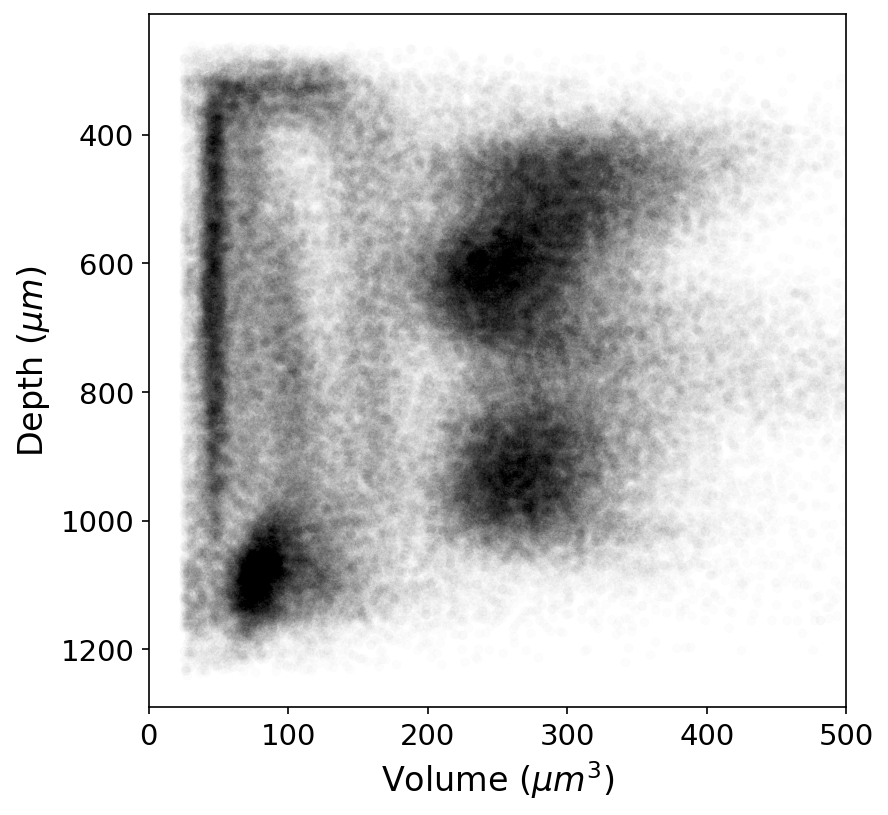

In [24]:
# @title Figure 7: Spatial Organization of Cell Nuclei in the tissue

fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
ax.tick_params(labelsize=14)
sns.scatterplot(data=nucleus_df, x="volume", y="pt_position_y", size=1, edgecolor=None, alpha=.01, color="k", ax=ax, legend=False)
ax.invert_yaxis()
ax.set_xlabel("Volume ($\mu m^3$)", fontsize=16)
ax.set_ylabel("Depth ($\mu m$)", fontsize=16)
ax.set_xlim(0, 500)
plt.show()

#### Cell types reveal structure in the data

When the cell type table contains the information about the nuclei, we can use it to plot the locations of all cell bodies as well and label them by type.

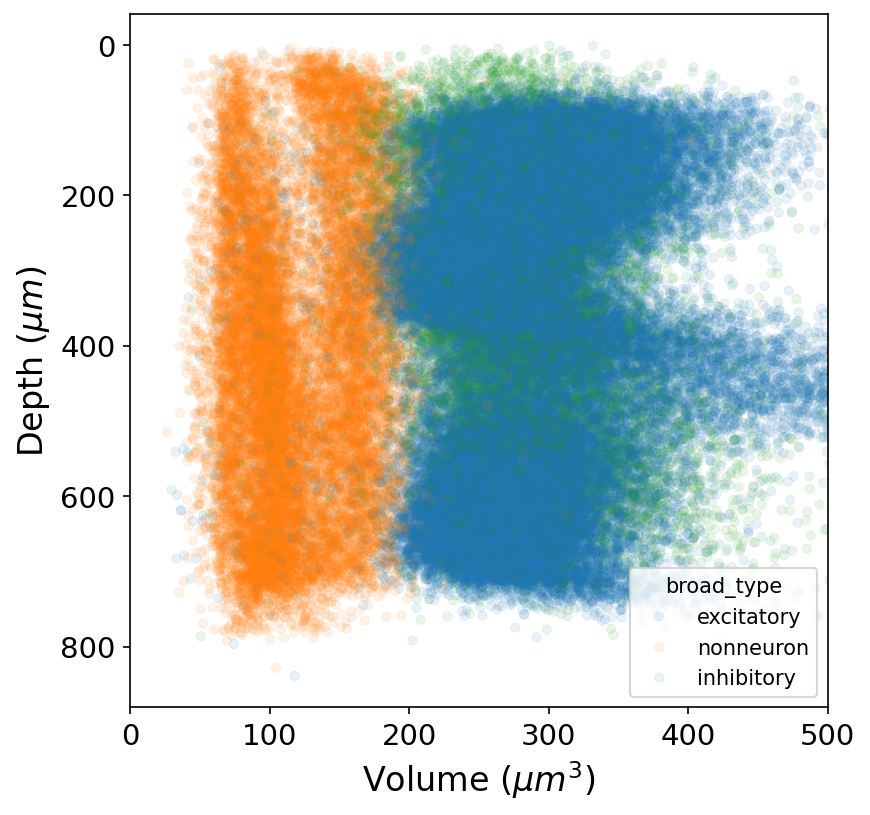

In [25]:
# @title Figure 7b: Spatial Organization of Cell Types (Excitatory, Inhibitory, non-neuronal) in the tissue

# merge cell nucleus size to cell type
if 'volume' not in cell_types_df.columns:
    cell_types_df = cell_types_df.merge(nucleus_df[['id','volume']])

fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
ax.tick_params(labelsize=14)
sns.scatterplot(data=cell_types_df.query("broad_type!='unknown'"),
                x="volume", y="pt_position_y_tform",
                s=20, edgecolor=None, alpha=.1, color="k", ax=ax,
                legend=True, hue="broad_type", )
ax.invert_yaxis()
ax.set_xlabel("Volume ($\mu m^3$)", fontsize=16)
ax.set_ylabel("Depth ($\mu m$)", fontsize=16)
ax.set_xlim(0, 500)
plt.show()

<mark> Student Task: Can you color a volume vs depth plot based on cell types?</mark>


Hint: look for the argument `hue`. It points to 'broad_type' above. What do you want it to point to instead?

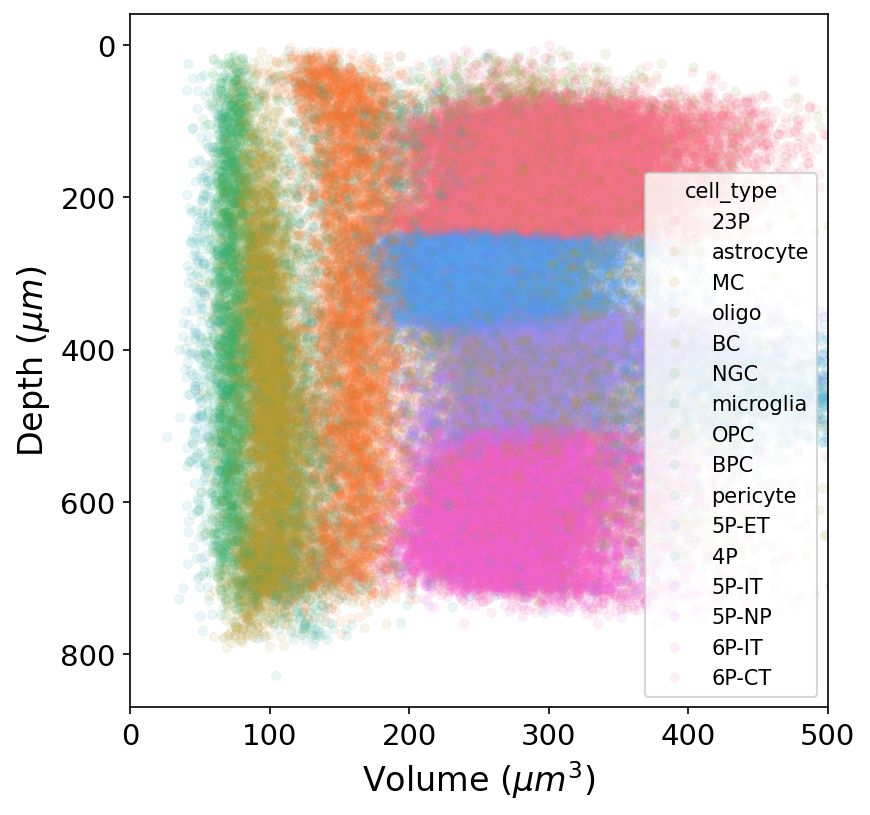

In [26]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
ax.tick_params(labelsize=14)
sns.scatterplot(data=cell_types_df.query("cell_type!='unknown'"), x="volume", y="pt_position_y_tform", s=20, edgecolor=None, alpha=.1, color="k", ax=ax,
                legend=True, hue="cell_type")
ax.invert_yaxis()
ax.set_xlabel("Volume ($\mu m^3$)", fontsize=16)
ax.set_ylabel("Depth ($\mu m$)", fontsize=16)
ax.set_xlim(0, 500)
plt.show()

<mark>Student Task 2: Can you create a volume vs depth plot for a single cell type?</mark>


Hint: you can 'filter' your `cell_types_df` to include only certain cell types. For example here is both layer 23 and 4P cells:

```
cell_types_df[cell_types_df['cell_type'].isin(['23P', '4P'])]
```


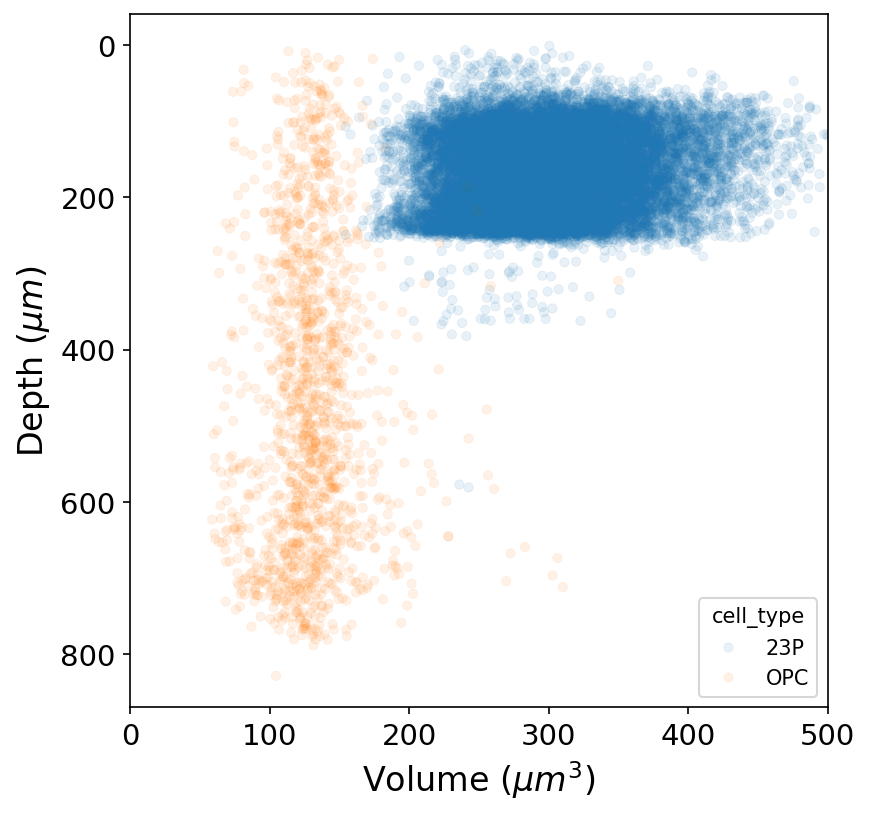

In [27]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
ax.tick_params(labelsize=14)

ct_df_filtered = cell_types_df[cell_types_df['cell_type'].isin(['23P', 'OPC'])]
sns.scatterplot(data=ct_df_filtered, x="volume", y="pt_position_y_tform", s=20, edgecolor=None, alpha=.1, color="k", ax=ax,
                legend=True, hue="cell_type")
ax.invert_yaxis()
ax.set_xlabel("Volume ($\\mu m^3$)", fontsize=16)
ax.set_ylabel("Depth ($\mu m$)", fontsize=16)
ax.set_xlim(0, 500)
plt.show()

<mark>Student Task: Can you plot these data to look for distribution of all inhibitory and excitatory cell types, in separate polts?</mark>

Hint: you can filter on 'broad_type' instead of cell type.

```
cell_types_df.query("broad_type=='excitatory'")
```

Hint: You can plot two plots, or put them side by side in a subplot with:

```
fig, axes = plt.subplots(1, 2,)

ax[0].plot_something

ax[1].plot_something

```

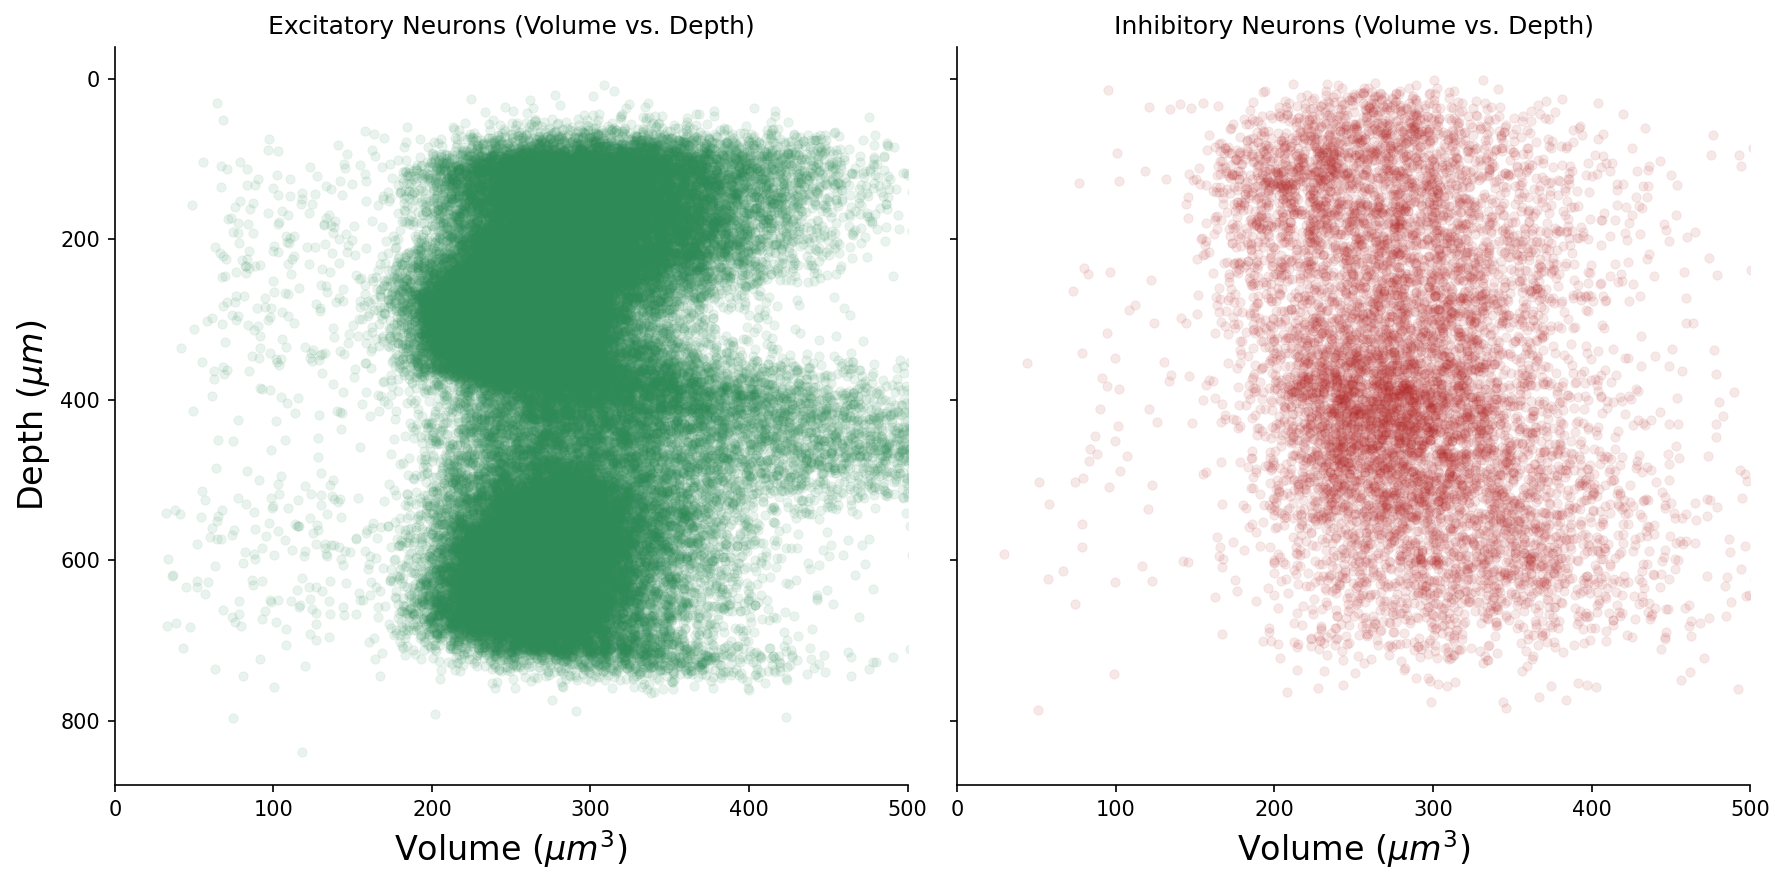

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=150, sharey=True)

# Excitatory cells
excitatory_cells_df = cell_types_df.query("broad_type=='excitatory'")
sns.scatterplot(data=excitatory_cells_df,
                x="volume", y="pt_position_y_tform",
                s=20, edgecolor=None, alpha=.1, color="seagreen", ax=axes[0])
axes[0].invert_yaxis()
axes[0].set_xlabel("Volume ($\mu m^3$)", fontsize=16)
axes[0].set_ylabel("Depth ($\mu m$)", fontsize=16)
axes[0].set_xlim(0, 500)
axes[0].set_title("Excitatory Neurons (Volume vs. Depth)")

# Inhibitory cells
inhibitory_cells_df = cell_types_df.query("broad_type=='inhibitory'")
sns.scatterplot(data=inhibitory_cells_df,
                x="volume", y="pt_position_y_tform",
                s=20, edgecolor=None, alpha=.1, color="firebrick", ax=axes[1])
axes[1].invert_yaxis()
axes[1].set_xlabel("Volume ($\mu m^3$)", fontsize=16)
axes[1].set_ylabel("Depth ($\mu m$)", fontsize=16) # Add ylabel for clarity
axes[1].set_xlim(0, 500)
axes[1].set_title("Inhibitory Neurons (Volume vs. Depth)")
axes[1].invert_yaxis()
sns.despine()
plt.tight_layout()
plt.show()

## Part 4: Sorting the synapse matrix with cell types
    
Let's combine the synaptic connecitivity with the cell type information. Below we provide logic for sorting a connectivity matrix using a list of labels.  

In [29]:
# @title Helper function: sort_matrix_by_types
def sort_matrix_by_types(mat: pd.DataFrame,
                         labels: pd.DataFrame,
                         label_type_col: str = "cell_type_auto",
                         label_id_col: str = "pt_root_id",
                         post_labels: pd.DataFrame = None,
                         post_label_type_col: str = None,
                         post_label_id_col: str = None):
    """Sorts (synapse) matrix by labels.

    This function assumes a square synapse matrix!

    Args:
        mat: synapse matrix as pandas DataFrame
        labels: DataFrame with labels, e.g. the output of client.materialize.query_table('aibs_metamodel_celltypes_v661')
        label_type_col: column name in labels for cell types
        label_id_col: column name in labels for root ids
        post_labels: DataFrame with labels, e.g. the output of client.materialize.query_table('aibs_metamodel_celltypes_v661')
        post_label_type_col: column name in labels for cell types
        post_label_id_col: column name in labels for root ids

    Returns:
        mat_sorted: sorted matrix
        mat_labels: sorted labels; has the same length as matrix
    """

    if post_labels is None:
        post_labels = labels
    if post_label_type_col is None:
        post_label_type_col = label_type_col
    if post_label_id_col is None:
        post_label_id_col = label_id_col

    mat_sorted = mat.copy()

    pre_mat_labels = np.array(labels.set_index(label_id_col).loc[mat_sorted.index][label_type_col])
    pre_sorting = np.argsort(pre_mat_labels)

    post_mat_labels = np.array(post_labels.set_index(post_label_id_col).loc[mat_sorted.T.index][post_label_type_col])
    post_sorting = np.argsort(post_mat_labels)

    mat_sorted = mat_sorted.iloc[pre_sorting].T.iloc[post_sorting].T

    return mat_sorted, pre_mat_labels[pre_sorting], post_mat_labels[post_sorting]

In [30]:
# Sort the column connectivity
syn_mat = column_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id",
                                            values="size", aggfunc=lambda x: np.log(np.sum(x))).fillna(0)

syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)

# sort the matrix by cell types to render sensibly in heatmap
cell_types_df = cell_types_df.fillna({'cell_type': 'unknown', 'broad_type': 'unknown', 'meso_type': 'unknown'})
syn_mat_ct, syn_mat_cell_types, _ = sort_matrix_by_types(syn_mat, cell_types_df, label_type_col="cell_type")

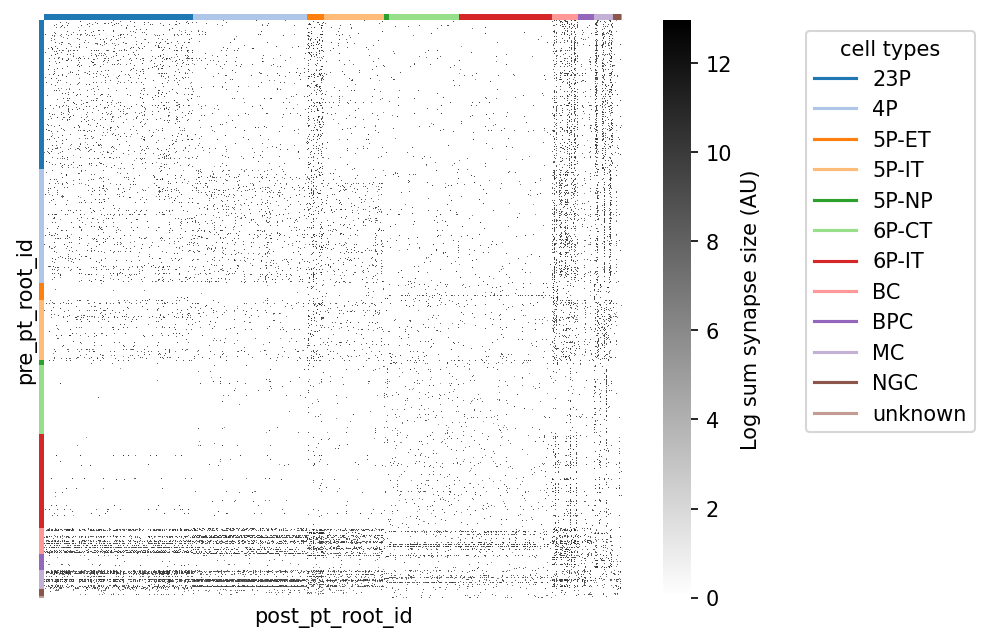

In [31]:
# @title Figure 8: Connectivity matrix sorted by cell type

# add colormap for cell type
cts, ct_idx = np.unique(syn_mat_cell_types, return_inverse=True)
ct_colors = plt.get_cmap("tab20")(ct_idx)

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
sns.heatmap(syn_mat_ct, cmap="gray_r", xticklabels=[], yticklabels=[],
            ax=ax, square=True,
            cbar_kws={"label": "Log sum synapse size (AU)"})


# Adding row and column colors for cell types
for i, color in enumerate(ct_colors):
    ax.add_patch(plt.Rectangle(xy=(-0.01, i), width=0.01, height=1, color=color, lw=0,
                               transform=ax.get_yaxis_transform(), clip_on=False))

for i, color in enumerate(ct_colors):
    ax.add_patch(plt.Rectangle(xy=(i, 1), height=0.01, width=1, color=color, lw=0,
                               transform=ax.get_xaxis_transform(), clip_on=False))

import matplotlib
# add a legend for the cell types
legend_elements = [matplotlib.lines.Line2D([0], [0], color=plt.get_cmap("tab20")(i), label=ct) for i, ct in enumerate(cts)]
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.3, 1), title="cell types")
plt.show()

## Supplementary Part 5: Nuances of connectivity

Up until now we have considered all synapses to be largely equivalent, a binary of connection between one cell and another cell. But this isn't actually true!

We wil go through four considerations for connection strength

### 1. Synapse size

For us, synaptic size means extent of the the postsynaptic density at every connection, effectively the surface area of the synapse and a metric of the 'active zone' of neurotransmitter release.

<i>Note:</i> The `size` reported in the MICrONS dataset measures the synaptic cleft as segmented by the automated classifier in voxels (3d pixels, a measure of volume). These are correlated to anatomical measures such as synaptic area and spine head volumes (for excitatory synapses).

This is generally aggregated as <code>sum</code> or <code>mean</code> for each unique connection.

In [32]:
# extract only the synapses between excitatory-excitatory cells in the column
excitatory_root_ids = cell_types_df.query("broad_type=='excitatory'").pt_root_id.to_numpy()

# Filter synapse table for excitatory-excitatory connections
exc_exc_synapses = column_synapses.loc[(column_synapses.pre_pt_root_id.isin(excitatory_root_ids) &
                                        column_synapses.post_pt_root_id.isin(excitatory_root_ids)
                                                 )]

np.shape(exc_exc_synapses)

(36233, 6)

[Text(0.5, 0, 'Sum synapse size (voxels - log scale)'),
 Text(0, 0.5, 'Number of connections')]

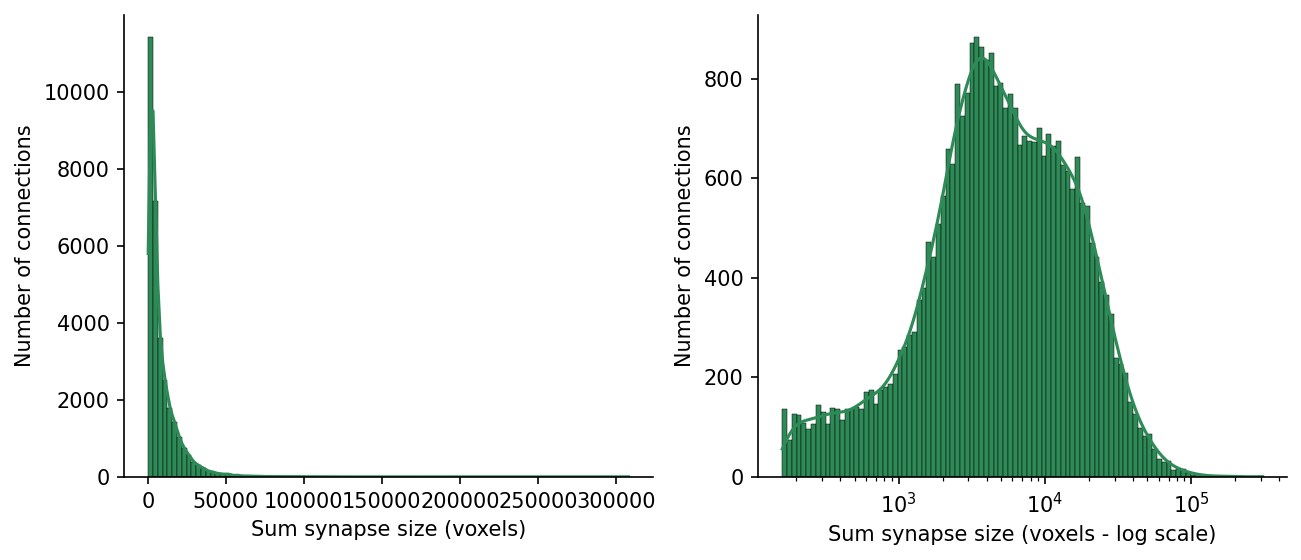

In [33]:
# @title Figure 9: Synapse size excitatory-to-excitatory connections

fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

syn_mat = exc_exc_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id",
                                            values="size", aggfunc=lambda x: (np.sum(x))).fillna(0)

# Make sure matrix is quadratic
syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)

# collect the synaptic weights that are non-zero
row_indices, column_indices = np.nonzero(syn_mat)
edge_weights = syn_mat.to_numpy()[row_indices, column_indices]

# Histogram on linear-x
ax = axs[0]
sns.histplot(
    edge_weights,
    kde=True,
    bins=100,
    ax=ax,
    log_scale=False,
    facecolor='seagreen',
)
ax.spines[["top", "right"]].set_visible(False)
ax.set(xlabel="Sum synapse size (voxels)", ylabel="Number of connections")

# Histogram on log-x
ax = axs[1]
sns.histplot(
    edge_weights,
    kde=True,
    bins=100,
    ax=ax,
    log_scale=True,
    facecolor='seagreen',
)
ax.spines[["top", "right"]].set_visible(False)
ax.set(xlabel="Sum synapse size (voxels - log scale)", ylabel="Number of connections")


Let's replot the <b>square matrix</b> with the log of the <code>sum</code> of synapses sizes between each connected pair `aggfunc=lambda x: np.log(np.sum(x))`

In [34]:
# matrix of log-summed synapse size
syn_mat_logsum = column_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id",
                                            values="size", aggfunc=lambda x: np.log(np.sum(x))).fillna(0)

# Make sure matrix is quadratic
syn_mat_logsum = syn_mat_logsum.reindex(columns=np.array(syn_mat.index)).astype(float)


Number of edges: 58840
Number of possible edges: 1611095
Fraction of possible edges: 0.0365


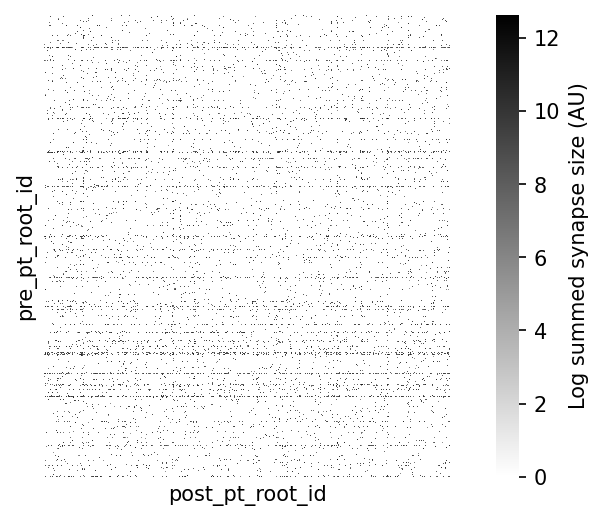

In [35]:
# @title Figure 10: Connectivity matrix, with synaptic strength (column-to-column)

fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
sns.heatmap(syn_mat_logsum, cmap="gray_r", xticklabels=[], yticklabels=[],
            ax=ax, square=True,
            cbar_kws={"label": "Log summed synapse size (AU)"})


row_indices, column_indices = np.nonzero(syn_mat_logsum)
n_edges = len(row_indices)
n_possible_edges = syn_mat_logsum.shape[0] * syn_mat_logsum.shape[1]
print(f"Number of edges: {n_edges}")
print(f"Number of possible edges: {n_possible_edges}")
print(f"Fraction of possible edges: {n_edges / n_possible_edges:.4f}")

In mouse visual cortex, the diversity in <b>Excitatory to excitatory</b> connectivity is much more bimodal in synaptic `size`. However, the size of <b>Inhibitory to excitatory</b> synapses more unimodal and smaller than the excitatory synapses, on average.

In [36]:
# Filter synapse table for inhibitory-excitatory connections
inhibitory_root_ids = cell_types_df.query("broad_type=='inhibitory'").pt_root_id.to_numpy()
inh_exc_synapses = column_synapses.loc[(column_synapses.pre_pt_root_id.isin(inhibitory_root_ids) &
                                        column_synapses.post_pt_root_id.isin(excitatory_root_ids)
                                                 )]
np.shape(inh_exc_synapses)

(72765, 6)

<mark>Student Task 1: Create the above **Figure 9** for inhibitory to excitatory synapses</mark> (color firebrick) . Label this figure as **Figure 9b**.

Hint: we just extracted these synapses as `inh_exc_synapses`. You can do the same thing as for `exc_exc_synapses` in Figure 9 EXCEPT this matrix will not be quadratic (we have different cells on the x and y of the graph). Drop that line.


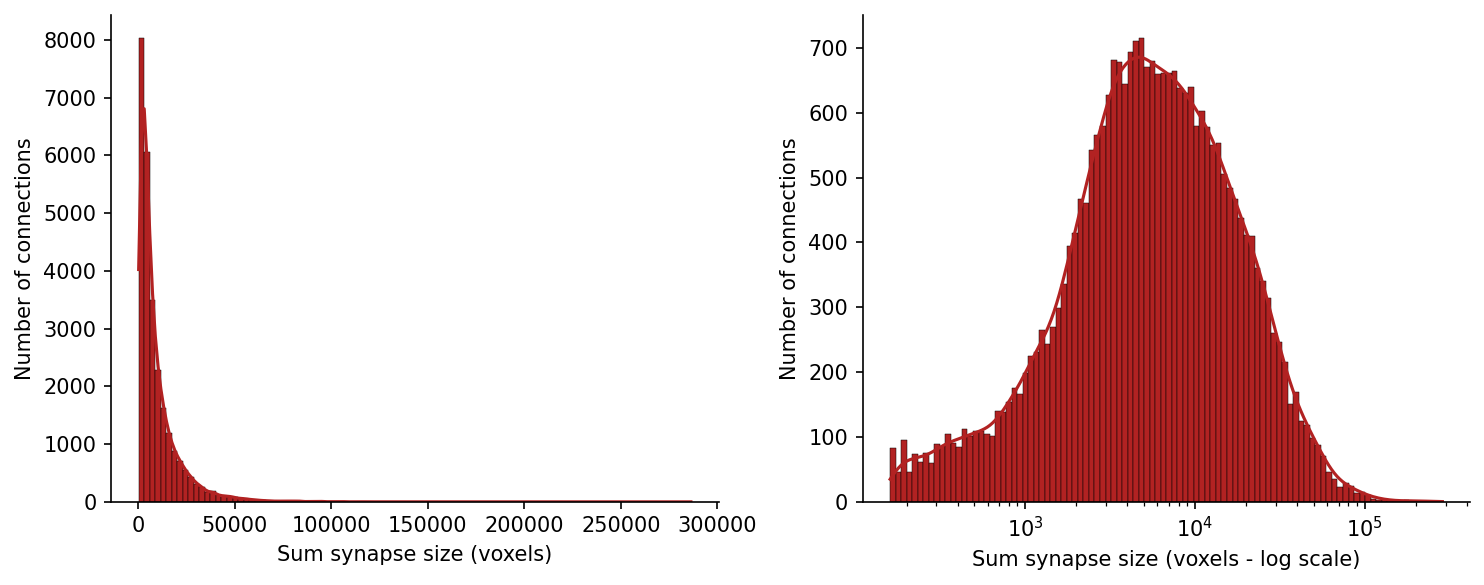

In [37]:
# @title Figure 9b: Synapse size inhibitory-to-inhibitory connections

fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

syn_mat = inh_exc_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id",
                                            values="size", aggfunc=lambda x: (np.sum(x))).fillna(0)

# This matrix will NOT be quadratic. this line is unnecessary
# syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)

# collect the synaptic weights that are non-zero
row_indices, column_indices = np.nonzero(syn_mat)
edge_weights = syn_mat.to_numpy()[row_indices, column_indices]

# Histogram on linear-x
ax = axs[0]
sns.histplot(
    edge_weights,
    kde=True,
    bins=100,
    ax=ax,
    log_scale=False,
    facecolor='firebrick',
)
ax.spines[["top", "right"]].set_visible(False)
ax.set(xlabel="Sum synapse size (voxels)", ylabel="Number of connections")

# Histogram on log-x
ax = axs[1]
sns.histplot(
    edge_weights,
    kde=True,
    bins=100,
    ax=ax,
    log_scale=True,
    facecolor='firebrick',
)
ax.spines[["top", "right"]].set_visible(False)
ax.set(xlabel="Sum synapse size (voxels - log scale)", ylabel="Number of connections")
plt.tight_layout()
plt.show()

<mark>Student Task 1: Create the above Figure 9 for inhibitory to inhibitory synapses</mark>. Label this figure as Figure 9c
  


In [38]:
# Filter synapse table for inhibitory-inhibitory connections
inhibitory_root_ids = cell_types_df.query("broad_type=='inhibitory'").pt_root_id.to_numpy()
inh_inh_synapses = column_synapses.loc[(column_synapses.pre_pt_root_id.isin(inhibitory_root_ids) &
                                        column_synapses.post_pt_root_id.isin(inhibitory_root_ids)
                                                 )]
np.shape(inh_inh_synapses)

(9417, 6)

### 2. Synapse count

This is the total number of synapses that are part of the connection. This is typical analysis in the the Fly connectome where <code>count</code> captures much of the connection diversity.

The modal <code>count</code> in mouse cortex is much lower.

[Text(0.5, 0, 'Number of synapses per connection'),
 Text(0, 0.5, 'Number of connections')]

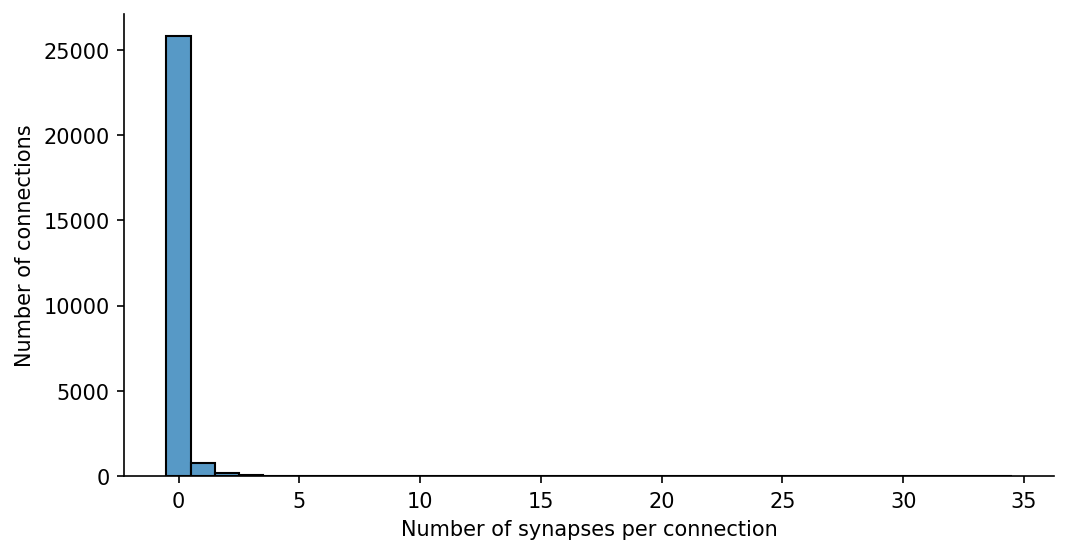

In [39]:
# @title Figure 11: Synapse count per connection

# Count Histogram on linear-x
syn_mat = column_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id",
                                            values="size", aggfunc=lambda x: np.sum(x > 0)).fillna(0)

# Make sure matrix is quadratic
syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)

fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
edge_weights = syn_mat.to_numpy()[row_indices, column_indices]
sns.histplot(
    edge_weights,
    discrete=True,
    ax=ax,
)
ax.spines[["top", "right"]].set_visible(False)
ax.set(xlabel="Number of synapses per connection", ylabel="Number of connections")

In other systems than mouse cortex, the number of synapses might be the more important measure (see [Dorkenwald et al., 2022](https://elifesciences.org/articles/76120) for deeper dive into synapse size and counts).

However, in mouse cortex the modal number of <b>Excitatory-to-excitatory connections is 1</b>, while inhibitory-excitatory connections may be more varied


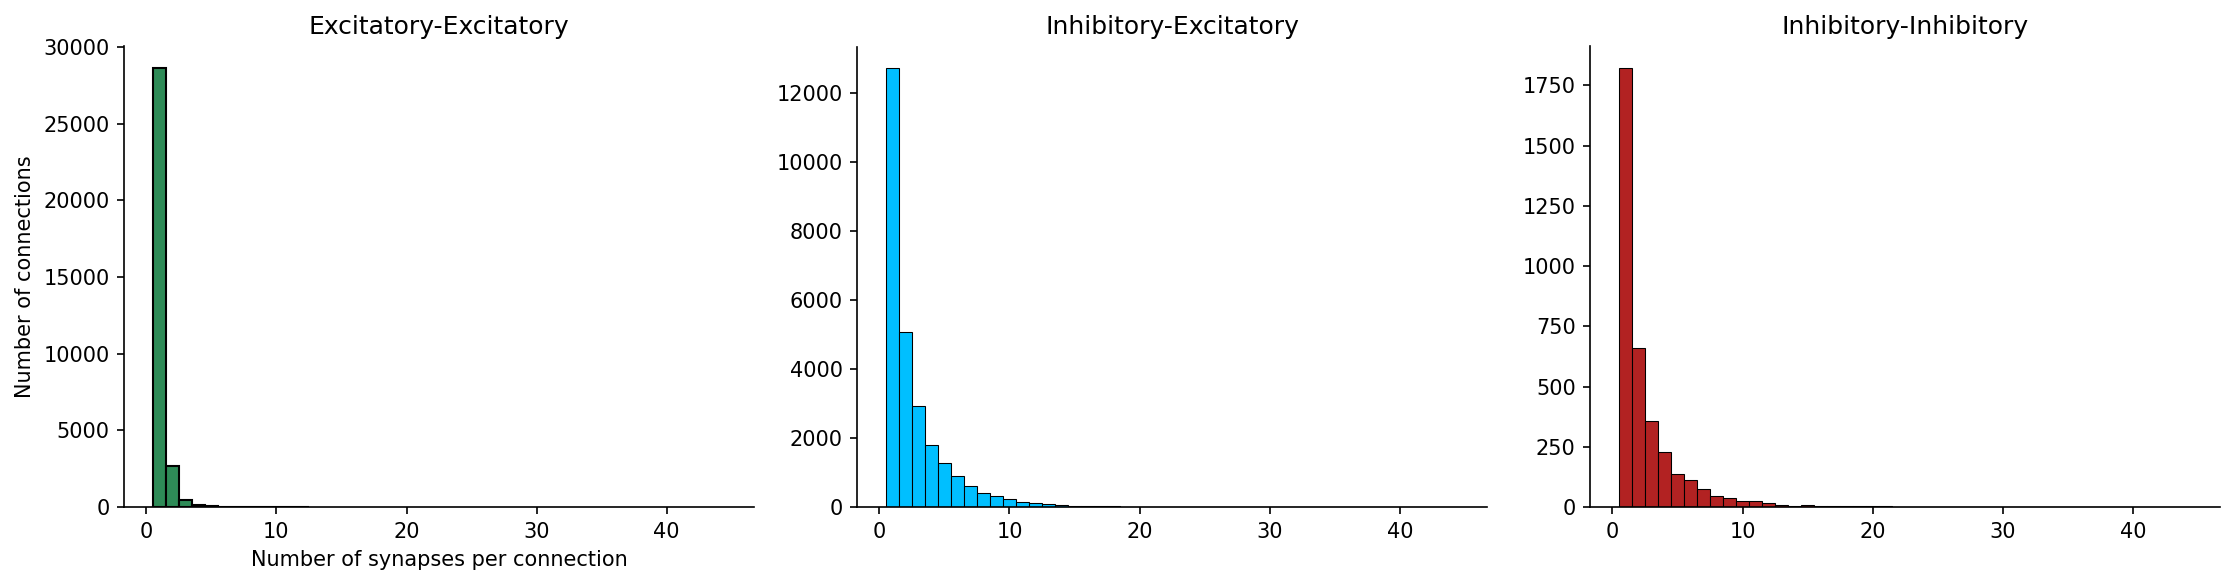

In [40]:
# @title Figure 12: Synapse count per connection differs for excitatory or inhibitory connections

fig, ax = plt.subplots(1,3, figsize=(15, 4),dpi=150, sharex=True)

syn_mat = exc_exc_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id",
                                       values="size", aggfunc=lambda x: np.sum(x > 0)).fillna(0)
# Make sure matrix is quadratic
syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)
row_indices, column_indices = np.nonzero(syn_mat)
edge_weights = syn_mat.to_numpy()[row_indices, column_indices]

sns.histplot(
    edge_weights,
    discrete=True,
    ax=ax[0],
    facecolor='seagreen',
)


syn_mat = inh_exc_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id",
                                       values="size", aggfunc=lambda x: np.sum(x > 0)).fillna(0)
## This matrix cannot be quadratic
# syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)
row_indices, column_indices = np.nonzero(syn_mat)
edge_weights = syn_mat.to_numpy()[row_indices, column_indices]

sns.histplot(
    edge_weights,
    discrete=True,
    ax=ax[1],
    facecolor='deepskyblue',
)

# Added code for Inhibitory-Inhibitory plot (Can be delegated as student task)
syn_mat = inh_inh_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id",
                                       values="size", aggfunc=lambda x: np.sum(x > 0)).fillna(0)
# Make sure matrix is quadratic
syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)
row_indices, column_indices = np.nonzero(syn_mat)
edge_weights = syn_mat.to_numpy()[row_indices, column_indices]

sns.histplot(
    edge_weights,
    discrete=True,
    ax=ax[2],
    facecolor='firebrick',
)

sns.despine()
ax[0].set(title='Excitatory-Excitatory', xlabel="Number of synapses per connection", ylabel="Number of connections")
ax[1].set(title='Inhibitory-Excitatory', ylabel=None)
ax[2].set(title='Inhibitory-Inhibitory', ylabel=None)

plt.tight_layout()

### 3. Synapse position and distance

Postsynaptic potentials onto to different dendritic compartments have to travel vastly different distances to reach the soma and 'summate' to trigger an action potential. This is something we can visualize by **computing the distance from every synapse to its soma**.

This is something Ossify is built to do, and can do it for our example **Layer 2/3 neuron** with two lines of code.

It's been a while, so let's retrieve the skeleton of our cell of interest:

In [42]:
import ossify

# Load skeleton with synaptic features
root_id = 864691135774053371 # known Layer 2/3 cell at v1718

cell = ossify.load_cell_from_client(
    root_id=root_id,
    client=client,
    synapses=True, # optional argument to load synapses with skeleton
    include_partner_root_id=True, # optional argument to load partner root ids with synapses
)

# Synapse dataframe attached to skeleton
pre_syn_df = cell.annotations.pre_syn.nodes
post_syn_df = cell.annotations.post_syn.nodes

In [43]:
### Calculate synapse distance to root

# Convert annotations to positional indices for algorithm
post_syn_indices = cell.annotations.post_syn.map_index_to_layer(
    "skeleton", as_positional=True
)
# compute distance to root for every annotation
distances_to_root = cell.skeleton.distance_to_root(post_syn_indices)
post_syn_df['distance_to_root'] = distances_to_root


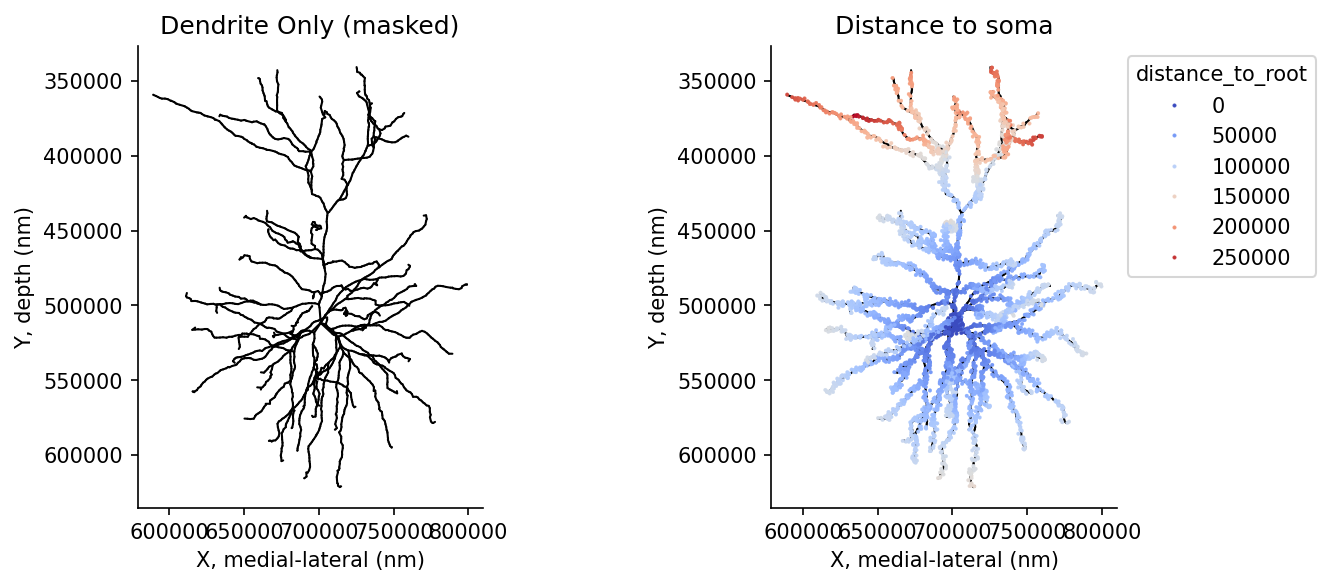

In [44]:
# @title Figure 13: Skeleton filtering and distance calculation

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

with cell.skeleton.mask_context(cell.skeleton.features['compartment'] != 2) as dendrite_cell:
    for i in range(2):
        ossify.plot.plot_morphology_2d(dendrite_cell,
                                       projection="xy",
                                       color="compartment",
                                       palette={1: 'navy', 2: 'dimgrey', 3: 'black'},
                                       ax=ax[i])

    dendrite_syn_ids= dendrite_cell.annotations.post_syn.nodes.index.to_numpy()



# Input synapses
sns.scatterplot(data=post_syn_df.loc[post_syn_df.index.isin(dendrite_syn_ids)],
                x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=3, hue='distance_to_root', palette= 'coolwarm',
                ax=ax[1], edgecolor=None, zorder=100)


ax[0].set(title="Dendrite Only (masked)", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
ax[1].set(title="Distance to soma", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
sns.despine()
sns.move_legend(ax[1], "upper left", bbox_to_anchor=(1, 1))
plt.show()

It is worth keeping in mind that connectivity is more than a binary.

### 4. Synapse  Distribution by Cell Type

Taking this connectivity information from one neuron, **quantify the synapses it makes onto all cell types**. This is the same process that happens to make the Dash App plots.

Note: here we work with only *unique* connections, even where there is more than one synapse between them

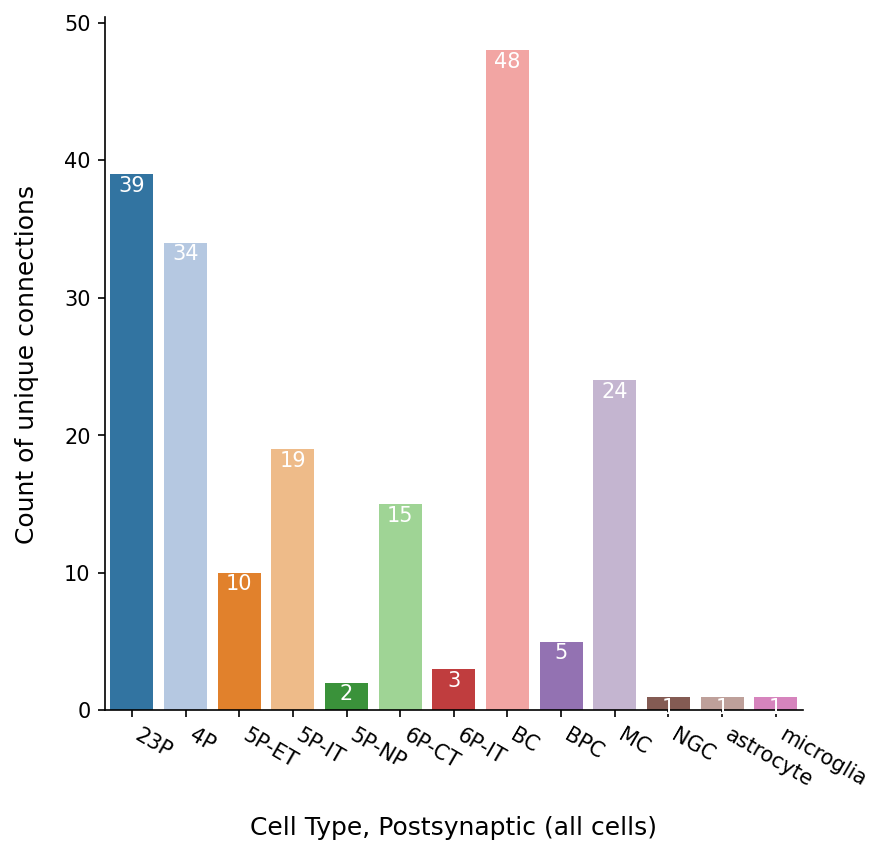

In [45]:
#Figure 14: Unique output connectivity

# First, find the unique postsynaptic partners
unique_postsyn_partners = pre_syn_df.post_pt_root_id.unique()

# Select the cell types of the postsynaptic partners
ct_postsyn_partners = cell_types_df.loc[cell_types_df.pt_root_id.isin(unique_postsyn_partners)]

# Make a bar plot of the connections to the postsynaptic cell types
ct_summary = (pd.DataFrame(ct_postsyn_partners.value_counts('cell_type'))
              .sort_values('cell_type')
              .reset_index()
             )

f, ax = plt.subplots(1,1, figsize=(6, 6),dpi=150)
sns.barplot(ct_summary, x='cell_type', y='count', hue='cell_type', palette='tab20', ax=ax)

# Add labels to the bars
for i, r in ct_summary.iterrows():
    ax.text(i, r['count']-.1, round(r['count'], 2),
            color='white', ha='center', va='top')

plt.ylabel('Count of unique connections', fontsize = 12, labelpad=12)
plt.xlabel('Cell Type, Postsynaptic (all cells)', fontsize = 12, labelpad=12)
plt.xticks(rotation=-30, ha='left')

sns.despine()

plt.show()

<mark>Student task 5: Can you create a similar graph for inputs? Copy-paste is allowed and encouraged</mark>

Hint: how do you invert this line:

```
unique_postsyn_partners = pre_syn_df.post_pt_root_id.unique()
```
to get: `unique_presyn_partners`

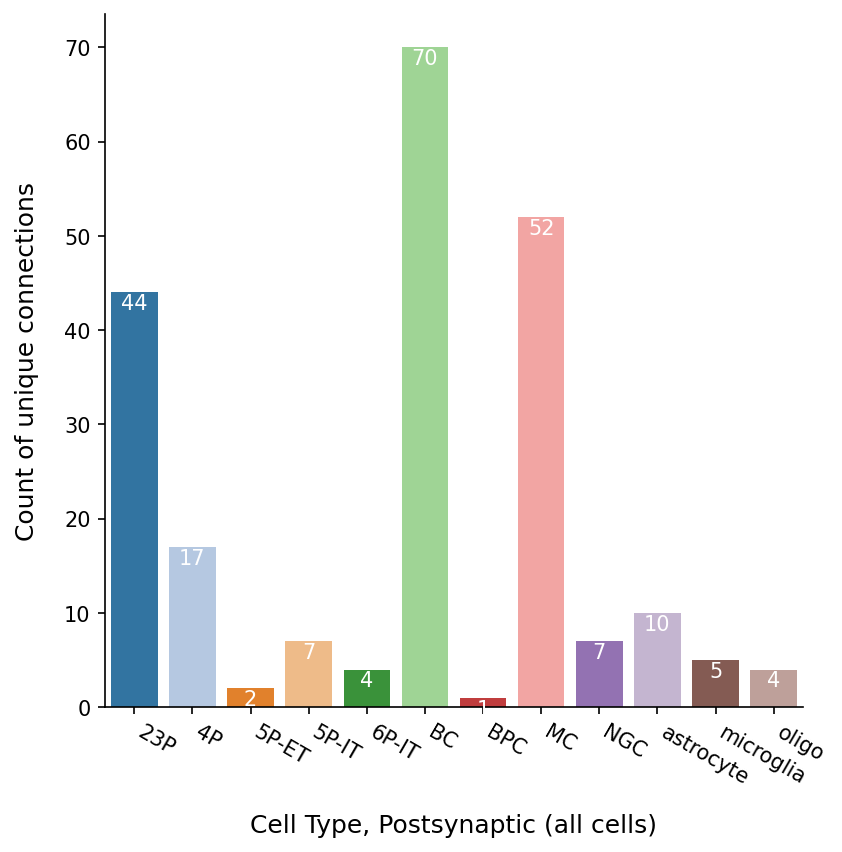

In [46]:
# First, find the unique postsynaptic partners
unique_presyn_partners = post_syn_df.pre_pt_root_id.unique()

# Select the cell types of the postsynaptic partners
ct_presyn_partners = cell_types_df.loc[cell_types_df.pt_root_id.isin(unique_presyn_partners)]

# Make a bar plot of the connections to the postsynaptic cell types
ct_summary = (pd.DataFrame(ct_presyn_partners.value_counts('cell_type'))
              .sort_values('cell_type')
              .reset_index()
             )

f, ax = plt.subplots(1,1, figsize=(6, 6),dpi=150)
sns.barplot(ct_summary, x='cell_type', y='count', hue='cell_type', palette='tab20', ax=ax)

# Add labels to the bars
for i, r in ct_summary.iterrows():
    ax.text(i, r['count']-.1, round(r['count'], 2),
            color='white', ha='center', va='top')

plt.ylabel('Count of unique connections', fontsize = 12, labelpad=12)
plt.xlabel('Cell Type, Postsynaptic (all cells)', fontsize = 12, labelpad=12)
plt.xticks(rotation=-30, ha='left')

sns.despine()

plt.show()

## Bonus Part 6: Advanced Neuroglancer

You can actually overlay many of these properties in neuroglancer, including:

* Skeletons: <https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/6025750544121856>
* Nucleus segmentation: <https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/4846103861133312>
* Cell Types: <https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5505896963637248>
* Proofreading Status: <https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5626062229733376>
* Synapses: <https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/6395755509055488>

And any combination thereof. Tip: drag layers between diferent neuroglancer windows to view overlaid



# Further resources:

In the repository for this data access tutorial, there is also

* Programmatic generation and parsing of neuroglancer states : `Tutorial_NGLUI.ipynb`
* Preprocessing used to collate the cell types information : `_preprocessing_celltypes_v1718.ipynb`


<b>Furter documentation</b>

* MICrONS Tutorials : [https://tutorial.microns-explorer.org/](https://tutorial.microns-explorer.org/)
* Connectome Annotation Versioning Engine CAVE : [https://www.caveconnecto.me/CAVEclient/tutorials/](https://www.caveconnecto.me/CAVEclient/tutorials/)
* Ossify : [https://csdashm.com/ossify/](https://csdashm.com/ossify/)